# **07 — Modelos Explicativos y Análisis de Importancia de Variables**
## Mercado Inmobiliario CABA · Fondo de Inversión

---

### Motivación analítica

Los notebooks anteriores respondieron *qué* pasa en el mercado (03), *si* las hipótesis se confirman (04), *qué estructura latente* tiene el espacio de variables (05) y *qué perfiles* existen (06). Este notebook responde **por qué**: ¿qué variables explican mejor la rentabilidad bruta anual de un departamento en CABA, y cuál es la magnitud de esa influencia?

El foco es **explicativo, no predictivo**. El objetivo no es construir un scoring para nuevas propiedades sino cuantificar relaciones estructurales del mercado que fundamenten las recomendaciones de inversión.

Tres modelos complementarios:
1. **OLS**: coeficientes con intervalos de confianza — efecto marginal ceteris paribus.
2. **Árbol de decisión**: captura no linealidades; genera reglas de decisión visualizables.
3. **Random Forest**: mayor robustez; importancia por permutación más confiable ante correlaciones residuales.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

print("Setup completado ✓")

Setup completado ✓


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Carga del dataset


In [3]:
URL_CLUSTERS = ('https://raw.githubusercontent.com/kiaranatale/'
                'Trabajo-Practico-Real-State-Analytics/refs/heads/main/'
                'Datos2/dataset_ventas_clusters.csv')
try:
    df = pd.read_csv(URL_CLUSTERS)
    print("Cargado desde GitHub ✓")
except Exception:
    try:
        df = pd.read_csv('dataset_ventas_clusters.csv')
        print("Cargado desde clusters local ✓")
    except Exception:
        df = pd.read_csv('dataset_ventas_pca_scores.csv')
        print("Cargado desde PCA scores ✓")

num_cols = ['Precio_m2_USD','Rentabilidad_bruta_anual','Rentabilidad_neta_anual',
            'Payback_anios','Yield_gap_vs_bonos','Sup_Cubierta_m2','Indice_amenities',
            'Distancia_subte_km','Distancia_parque_km','Tasa_delitos_comuna',
            'Liquidez_oferta_comuna','Volatilidad_Precio_m2_comuna','A_estrenar']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Filtro confianza_renta: los modelos de rentabilidad requieren renta estimada confiable
if 'confianza_renta' in df.columns:
    n_antes = len(df)
    df_m = df[df['confianza_renta'] != 'baja'].copy().reset_index(drop=True)
    print(f"Filtro confianza_renta≠baja: {n_antes:,} → {len(df_m):,}")
else:
    df_m = df.copy()

TARGET = 'Rentabilidad_bruta_anual'
print(f"\nDataset para modelado: {df_m.shape}")
print(f"Variable objetivo: {TARGET}")
print(f"  Mediana: {df_m[TARGET].median():.4f}  |  Std: {df_m[TARGET].std():.4f}")

Cargado desde clusters local ✓
Filtro confianza_renta≠baja: 3,140 → 3,140

Dataset para modelado: (3140, 23)
Variable objetivo: Rentabilidad_bruta_anual
  Mediana: 0.0621  |  Std: 0.0578


## 2. Variables modelables — decisión explícita

Este paso es central en el pipeline: definimos formalmente qué variables entran a los modelos y por qué. La taxonomía construida en el notebook 05 es la base de esta decisión.


In [4]:
# ── Variables excluidas por razones de calidad de dato o tautología ──────────
EXCLUIDAS = {
    'Antiguedad':
        'Bug de imputación: >60% concentrado artificialmente en ~40 años. '
        'Solo A_estrenar (binario reconstruido vía URL) es confiable.',
    'Payback_anios':
        'Derivada algebraica de Rentabilidad_bruta_anual (=1/R). Incluirla '
        'sería tautológica con el target.',
    'Yield_gap_vs_bonos':
        'Derivada de Rentabilidad_bruta_anual (= R - 0.10). Misma razón.',
    'Rentabilidad_neta_anual':
        'Derivada de Rentabilidad_bruta_anual con ajustes fijos. '
        'Introduce redundancia sin información nueva.',
    'Precio_USD':
        'Colineal con Precio_m2_USD × Sup_Cubierta_m2 por construcción.',
    'Precio_m2_mediano_comuna':
        'Alta colinealidad con Precio_m2_USD (misma variable agregada por comuna).',
}

print("VARIABLES EXCLUIDAS DE LOS MODELOS — JUSTIFICACIÓN")
print("="*70)
for var, razon in EXCLUIDAS.items():
    print(f"\n✗ {var}")
    print(f"  {razon}")

# ── Features modelables ───────────────────────────────────────────────────────
FEATURES_BASE = [
    'Precio_m2_USD',             # Observada — precio de mercado por m²
    'Sup_Cubierta_m2',           # Observada — tamaño del activo
    'Distancia_subte_km',        # Observada (calculada) — accesibilidad
    'Distancia_parque_km',       # Observada (calculada) — calidad ambiental
    'Liquidez_oferta_comuna',    # Observada — escalabilidad del mercado
    'Tasa_delitos_comuna',       # Observada (fuente externa) — riesgo de zona
    'Volatilidad_Precio_m2_comuna', # Imputada (agregado comunal) — riesgo de valuación
    'Indice_amenities',          # Observada — calidad del activo
    'A_estrenar',                # Observada (reconstruida vía URL) — condición
]
CAT_FEATURES = [c for c in ['Tipologia', 'Zona_riesgo'] if c in df_m.columns]

print(f"\n\nFEATURES MODELABLES: {len(FEATURES_BASE)} continuas + {len(CAT_FEATURES)} categóricas")
for f in FEATURES_BASE:
    origen = 'OBSERVADA' if f not in ['Volatilidad_Precio_m2_comuna','Renta_estimada_mensual_USD'] else 'IMPUTADA'
    print(f"  {origen:10s}  {f}")
for f in CAT_FEATURES:
    print(f"  CATEGÓRICA  {f}")

VARIABLES EXCLUIDAS DE LOS MODELOS — JUSTIFICACIÓN

✗ Antiguedad
  Bug de imputación: >60% concentrado artificialmente en ~40 años. Solo A_estrenar (binario reconstruido vía URL) es confiable.

✗ Payback_anios
  Derivada algebraica de Rentabilidad_bruta_anual (=1/R). Incluirla sería tautológica con el target.

✗ Yield_gap_vs_bonos
  Derivada de Rentabilidad_bruta_anual (= R - 0.10). Misma razón.

✗ Rentabilidad_neta_anual
  Derivada de Rentabilidad_bruta_anual con ajustes fijos. Introduce redundancia sin información nueva.

✗ Precio_USD
  Colineal con Precio_m2_USD × Sup_Cubierta_m2 por construcción.

✗ Precio_m2_mediano_comuna
  Alta colinealidad con Precio_m2_USD (misma variable agregada por comuna).


FEATURES MODELABLES: 9 continuas + 2 categóricas
  OBSERVADA   Precio_m2_USD
  OBSERVADA   Sup_Cubierta_m2
  OBSERVADA   Distancia_subte_km
  OBSERVADA   Distancia_parque_km
  OBSERVADA   Liquidez_oferta_comuna
  OBSERVADA   Tasa_delitos_comuna
  IMPUTADA    Volatilidad_Precio_m2_comun

In [5]:
# ── Construcción del dataset de modelado ─────────────────────────────────────
df_model_raw = df_m[FEATURES_BASE + CAT_FEATURES + [TARGET]].dropna().copy()

if CAT_FEATURES:
    df_encoded = pd.get_dummies(df_model_raw, columns=CAT_FEATURES, drop_first=True)
else:
    df_encoded = df_model_raw.copy()

feature_cols = [c for c in df_encoded.columns if c != TARGET]
scaler = StandardScaler()
X_std = scaler.fit_transform(df_encoded[feature_cols].values)
y = df_encoded[TARGET].values

print(f"Dataset de modelado: {len(df_encoded):,} obs × {len(feature_cols)} features")
print(f"Features: {feature_cols}")

Dataset de modelado: 3,140 obs × 14 features
Features: ['Precio_m2_USD', 'Sup_Cubierta_m2', 'Distancia_subte_km', 'Distancia_parque_km', 'Liquidez_oferta_comuna', 'Tasa_delitos_comuna', 'Volatilidad_Precio_m2_comuna', 'Indice_amenities', 'A_estrenar', 'Tipologia_3A', 'Tipologia_4+A', 'Tipologia_monoamb', 'Zona_riesgo_bajo', 'Zona_riesgo_medio']


## 3. Diagnóstico de multicolinealidad (VIF pre-modelado)

Verificamos la multicolinealidad entre features **antes** de entrenar los modelos. Este paso justifica el uso de Random Forest (más robusto ante VIF moderados) sobre OLS como modelo principal para la importancia de variables.


In [6]:
vif_df = pd.DataFrame({
    'Feature': feature_cols,
    'VIF': [variance_inflation_factor(X_std, i) for i in range(X_std.shape[1])]
}).sort_values('VIF', ascending=False)

print("VIF por feature:")
for _, row in vif_df.iterrows():
    diag = "✗ Severa" if row['VIF'] > 10 else "⚠ Moderada" if row['VIF'] > 5 else "✓ OK"
    bar = '█' * min(int(row['VIF']), 20)
    print(f"  {row['Feature']:45s}  {row['VIF']:6.2f}  {bar:<20}  {diag}")

print(f"\n→ Variables con VIF > 10: {sum(vif_df['VIF'] > 10)}")
print("→ Si existen, considerar usar componentes PCA del nb05 como features alternativas.")

VIF por feature:
  Zona_riesgo_bajo                                 5.49  █████                 ⚠ Moderada
  Tasa_delitos_comuna                              4.64  ████                  ✓ OK
  Zona_riesgo_medio                                3.24  ███                   ✓ OK
  Tipologia_4+A                                    2.46  ██                    ✓ OK
  Sup_Cubierta_m2                                  2.09  ██                    ✓ OK
  Liquidez_oferta_comuna                           1.64  █                     ✓ OK
  Distancia_subte_km                               1.62  █                     ✓ OK
  Tipologia_3A                                     1.54  █                     ✓ OK
  Precio_m2_USD                                    1.50  █                     ✓ OK
  Distancia_parque_km                              1.49  █                     ✓ OK
  Tipologia_monoamb                                1.46  █                     ✓ OK
  Volatilidad_Precio_m2_comuna                     1.

**Hallazgo clave — multicolinealidad:** ninguna variable supera VIF = 10 — no hay
multicolinealidad severa. El único caso moderado es `Zona_riesgo_bajo` (VIF = 5.49),
esperado porque las dummies de zona de riesgo son complementarias entre sí (bajo +
medio + alto = 1). Esta colinealidad estructural entre dummies no afecta la validez
del modelo pero sí infla los errores estándar de los coeficientes de zona — los IC
del OLS para esas variables serán más anchos de lo ideal. El Random Forest no se ve
afectado por este VIF moderado.

El resto de las features tienen VIF entre 1.0 y 2.5, indicando que operan como
dimensiones prácticamente independientes en el modelo. Esto es consistente con los
resultados del nb05: las correlaciones intervariables son bajas (KMO = 0.42), por
lo que no había redundancia estructural entre features que eliminar.

**Implicación para la elección del modelo principal:** dado que no hay multicolinealidad
severa, el OLS es válido para leer los coeficientes ceteris paribus. Sin embargo, el
Random Forest sigue siendo la referencia para importancia de variables porque captura
no linealidades e interacciones que el OLS no modela — no por necesidad de robustez
ante VIF, sino por la naturaleza no lineal de la relación features → rentabilidad
(documentada en nb04).

## 4. Modelo 1: Regresión lineal OLS

OLS con errores estándar robustos (HC3) si el test de Breusch-Pagan detecta heterocedasticidad. Los coeficientes sobre datos estandarizados son betas comparables entre sí.


In [7]:
X_ols = sm.add_constant(X_std)
model_ols = sm.OLS(y, X_ols).fit()

# Test de supuestos
residuos = model_ols.resid
stat_bp, p_bp, _, _ = het_breuschpagan(residuos, X_ols)
stat_sw, p_sw = stats.shapiro(residuos[:min(5000, len(residuos))])

print(f"R² = {model_ols.rsquared:.4f}  |  R² ajustado = {model_ols.rsquared_adj:.4f}")
print(f"Shapiro-Wilk  (normalidad):    p = {p_sw:.4f}  → {'✓ Normal' if p_sw > 0.05 else '✗ No normal'}")
print(f"Breusch-Pagan (homoced.):      p = {p_bp:.4f}  → {'✓ Homocedástico' if p_bp > 0.05 else '✗ Heterocedástico → usando HC3'}")

if p_bp < 0.05:
    model_ols = model_ols.get_robustcov_results(cov_type='HC3')
    print("  → Modelo re-estimado con errores estándar robustos HC3")

R² = 0.3300  |  R² ajustado = 0.3270
Shapiro-Wilk  (normalidad):    p = 0.0000  → ✗ No normal
Breusch-Pagan (homoced.):      p = 0.0000  → ✗ Heterocedástico → usando HC3
  → Modelo re-estimado con errores estándar robustos HC3


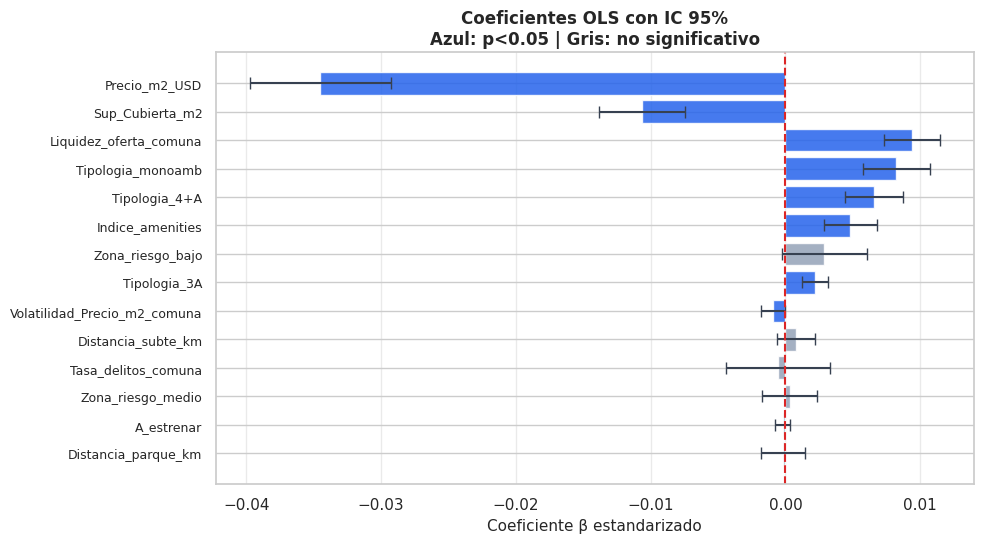

In [8]:
# ── Gráfico de coeficientes ────────────────────────────────────────────────────
ci = np.asarray(model_ols.conf_int())
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coef': np.asarray(model_ols.params)[1:],
    'p': np.asarray(model_ols.pvalues)[1:],
    'IC_low': ci[1:, 0],
    'IC_high': ci[1:, 1],
}).sort_values('Coef', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, len(coef_df)*0.4)))
colors = ['#2563eb' if p < 0.05 else '#94a3b8' for p in coef_df['p']]
ax.barh(range(len(coef_df)), coef_df['Coef'], color=colors, alpha=0.85, edgecolor='white')
ax.errorbar(coef_df['Coef'], range(len(coef_df)),
            xerr=[coef_df['Coef']-coef_df['IC_low'], coef_df['IC_high']-coef_df['Coef']],
            fmt='none', color='#374151', capsize=4, lw=1.5)
ax.axvline(0, color='#dc2626', ls='--', lw=1.5)
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df['Feature'], fontsize=9)
ax.set_xlabel('Coeficiente β estandarizado', fontsize=11)
ax.set_title('Coeficientes OLS con IC 95%\nAzul: p<0.05 | Gris: no significativo',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

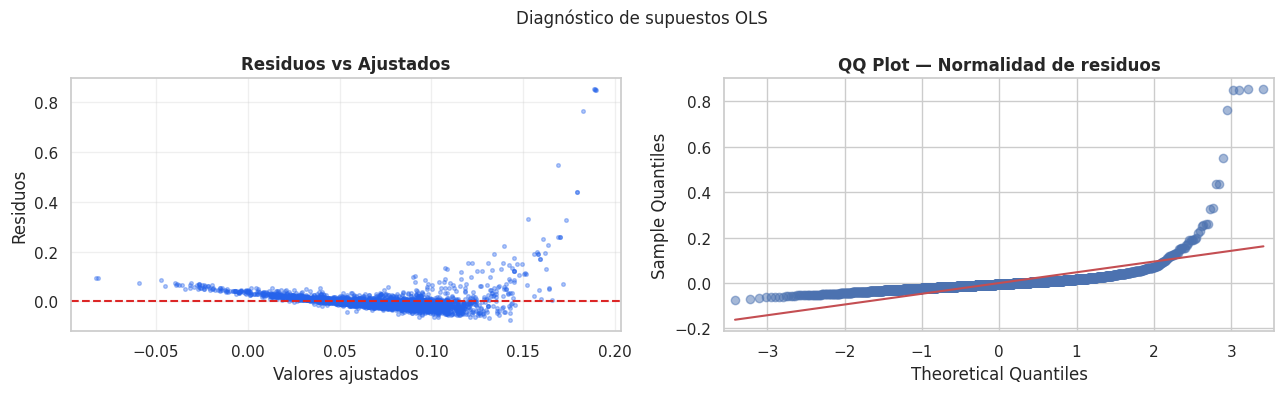

In [9]:
# ── Diagnóstico de residuos ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(model_ols.fittedvalues, residuos, alpha=0.35, s=7, color='#2563eb')
axes[0].axhline(0, color='#dc2626', ls='--', lw=1.5)
axes[0].set(xlabel='Valores ajustados', ylabel='Residuos', title='Residuos vs Ajustados')
axes[0].grid(alpha=0.3)

sm.qqplot(residuos, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('QQ Plot — Normalidad de residuos')

plt.suptitle('Diagnóstico de supuestos OLS', fontsize=12)
plt.tight_layout()
plt.show()

**Hallazgo clave — OLS:**

**Diagnóstico de supuestos:** Shapiro-Wilk (p=0.000) rechaza normalidad y Breusch-Pagan
(p=0.000) detecta heterocedasticidad — ambos visibles en los gráficos. El residuos vs
ajustados muestra un patrón de embudo claro: la varianza de los residuos crece con los
valores ajustados, confirmando heterocedasticidad. El QQ plot muestra colas pesadas,
especialmente en el extremo superior. El modelo fue re-estimado con errores estándar
robustos HC3, lo que hace los IC y p-valores reportados válidos pese a la violación
de supuestos. R² ajustado = 0.327 — el modelo lineal captura el 33% de la varianza
de la rentabilidad, lo cual es el piso explicativo del componente lineal.

**Variables significativas (p < 0.05, barras azules):**
- `Precio_m2_USD` (β ≈ −0.034): el efecto negativo más fuerte del modelo. A mayor
  precio por m², menor rentabilidad — resultado mecánico del yield (= renta/precio)
  y confirmación de que el premium de zonas caras no se traslada proporcionalmente
  a la renta. Consistente con el hallazgo central del nb06.
- `Sup_Cubierta_m2` (β ≈ −0.011): segundo efecto negativo más fuerte. La renta no
  escala 1:1 con la superficie — coherente con H2 (departamentos grandes tienen
  peor yield).
- `Liquidez_oferta_comuna` (β positivo): zonas con mayor oferta relativa tienen
  mayor rentabilidad. Puede reflejar que las comunas con más stock son las que
  presentan mayor competencia de precios de venta, comprimiendo el precio de compra
  más que el alquiler.
- `Tipologia_monoamb` y `Tipologia_4+A` (β positivos, categoría de referencia: 2A):
  ambas tipologías extremas rinden más que el 2 ambientes. Confirma el patrón en U
  de H2 con el OLS controlando por precio y superficie.
- `Indice_amenities` (β positivo): contra la intuición, más amenities se asocian
  con mayor yield controlando por precio. Sugiere que los amenities atraen demanda
  de alquiler sin necesariamente elevar el precio de compra en la misma proporción.
- `Tipologia_3A` (β positivo pequeño): efecto marginal respecto a 2A.

**Variables no significativas (barras grises):**
- `Zona_riesgo_bajo`, `Tasa_delitos_comuna`, `Zona_riesgo_medio`: el efecto de la
  zona de riesgo sobre la rentabilidad no es lineal — el OLS no lo captura. Consistente
  con H5 del nb04, donde el efecto del riesgo sobre el yield fue visible pero no
  lineal.
- `Distancia_subte_km`, `Distancia_parque_km`: sin efecto significativo en OLS,
  coherente con H1 y H3 refutadas.
- `A_estrenar`: efecto no significativo en OLS a pesar de que H4 fue validada en
  nb04. El OLS no captura el efecto no lineal de la condición sobre el yield una
  vez que se controla por precio y superficie.
- `Volatilidad_Precio_m2_comuna`: sin efecto lineal significativo.

**Implicación:** el OLS captura la parte lineal de la relación. Las variables no
significativas acá no deben descartarse — el Random Forest puede capturar sus efectos
no lineales e interacciones en la sección 6.

## 5. Modelo 2: Árbol de decisión

Busca la profundidad óptima por validación cruzada para evitar overfitting.


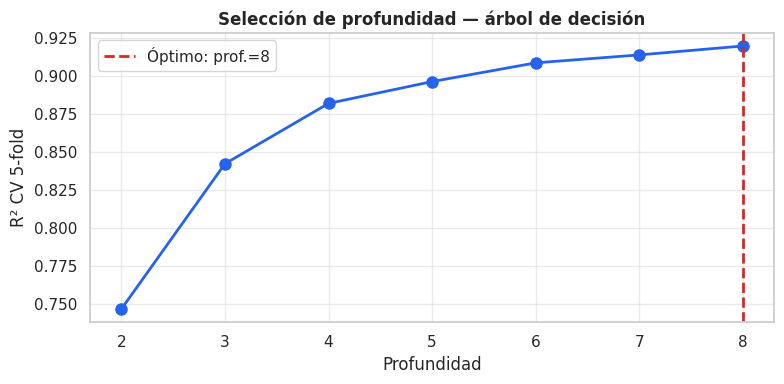

Profundidad óptima: 8  |  R² CV: 0.9198


In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
profundidades = range(2, 9)
cv_scores_dt = []
for d in profundidades:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    cv_scores_dt.append(cross_val_score(dt, X_std, y, cv=kf, scoring='r2').mean())

best_depth = list(profundidades)[cv_scores_dt.index(max(cv_scores_dt))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(profundidades, cv_scores_dt, 'o-', color='#2563eb', lw=2, ms=8)
ax.axvline(best_depth, color='#dc2626', ls='--', lw=2, label=f'Óptimo: prof.={best_depth}')
ax.set(xlabel='Profundidad', ylabel='R² CV 5-fold', title='Selección de profundidad — árbol de decisión')
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Profundidad óptima: {best_depth}  |  R² CV: {max(cv_scores_dt):.4f}")

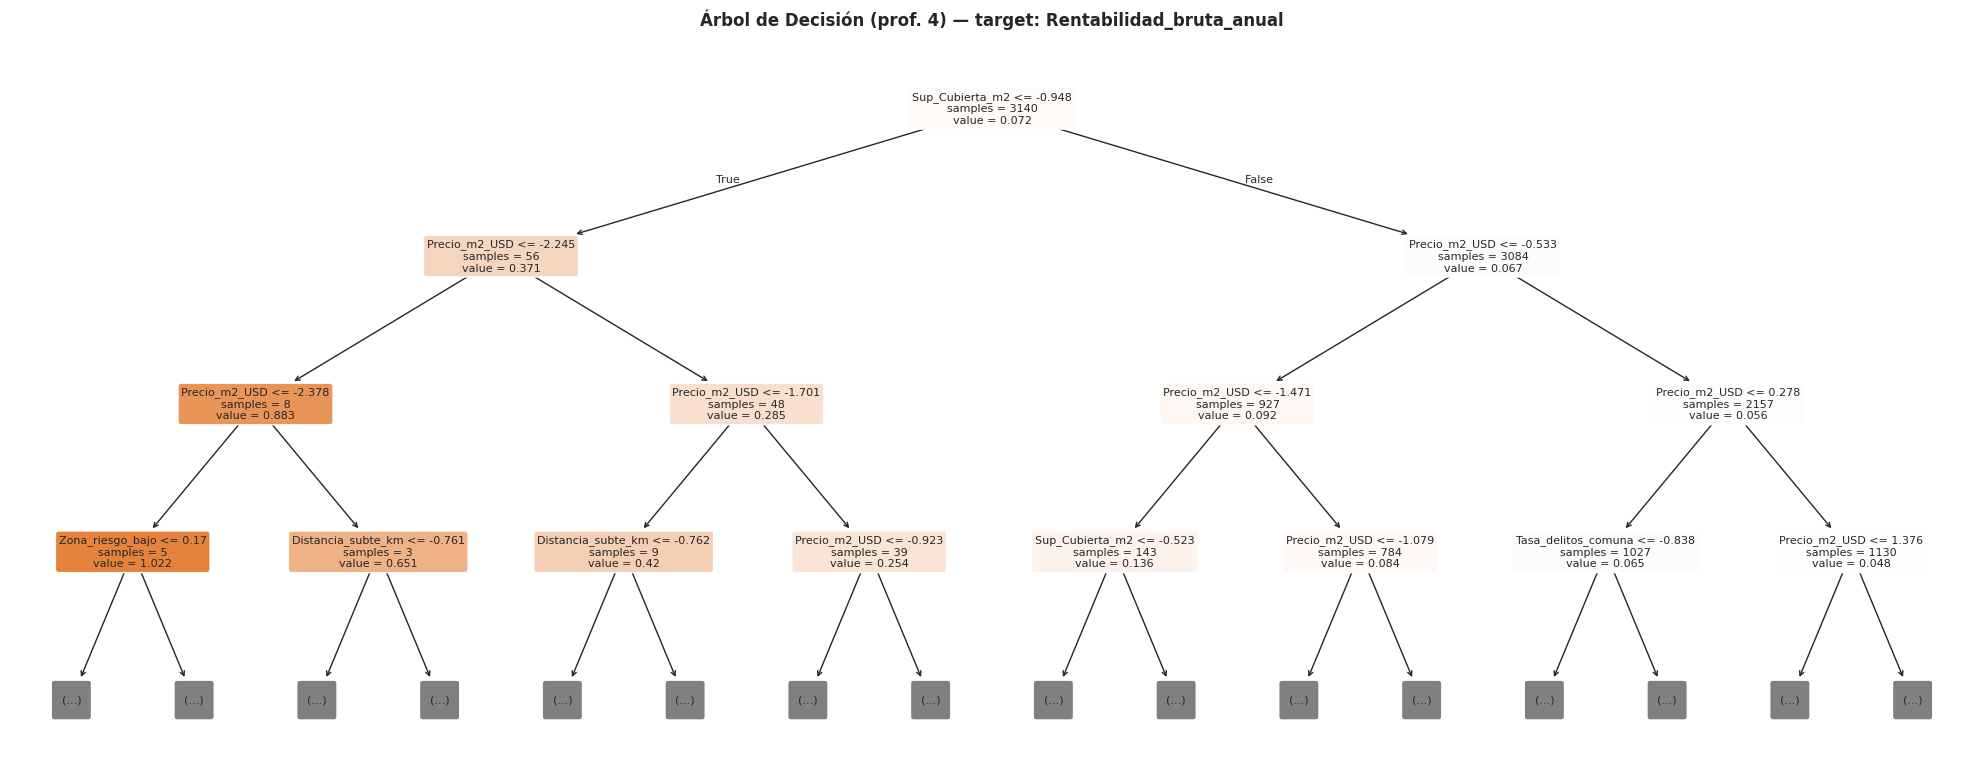


Primeras reglas del árbol:
|--- Sup_Cubierta_m2 <= -0.95
|   |--- Precio_m2_USD <= -2.24
|   |   |--- Precio_m2_USD <= -2.38
|   |   |   |--- Zona_riesgo_bajo <= 0.17
|   |   |   |   |--- value: [0.95]
|   |   |   |--- Zona_riesgo_bajo >  0.17
|   |   |   |   |--- value: [1.04]
|   |   |--- Precio_m2_USD >  -2.38
|   |   |   |--- Distancia_subte_km <= -0.76
|   |   |   |   |--- value: [0.72]
|   |   |   |--- Distancia_subte_km >  -0.76
|   |   |   |   |--- value: [0.62]
|   |--- Precio_m2_USD >  -2.24
|   |   |--- Precio_m2_USD <= -1.70
|   |   |   |--- Distancia_subte_km <= -0.76
|   |   |   |   |--- value: [0.37]
|   |   |   |--- Distancia_subte_km >  -0.76
|   |   |   |   |--- value: [0.45]
|   |   |--- Precio_m2_USD >  -1.70
|   |   |   |--- Precio_m2_USD <= -0.92
|   |   |   |   |--- value: [0.28]
|   |   |   |--- Precio_m2_USD >  -0.92
|   |   |   |   |--- value: [0.19]
|--- Sup_Cubierta_m2 >  -0.95
|   |--- Precio_m2_USD <= -0.53
|   |   |--- Precio_m2_USD <= -1.47
|   |   |   

In [12]:
# ── Árbol final ───────────────────────────────────────────────────────────────
VIZ_DEPTH = min(best_depth, 4)
dt_final = DecisionTreeRegressor(max_depth=VIZ_DEPTH, random_state=42)
dt_final.fit(X_std, y)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_final, feature_names=feature_cols, filled=True, rounded=True,
          fontsize=8, ax=ax, max_depth=3, impurity=False)
ax.set_title(f'Árbol de Decisión (prof. {VIZ_DEPTH}) — target: Rentabilidad_bruta_anual',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nPrimeras reglas del árbol:")
print("\n".join(export_text(dt_final, feature_names=feature_cols, max_depth=3).split("\n")[:35]))

**Caveat metodológico — discretización del target.** El R² CV alto del árbol (0.92) refleja una propiedad del target, no una capacidad predictiva real. La columna `Rentabilidad_bruta_anual` se calcula como `Renta_estimada_mensual_USD × 12 / Precio_ajustado_USD`, donde la renta estimada se hereda de la **tabla puente** del nb02: todas las propiedades en la misma celda `(Comuna, Tipología, banda_sup)` reciben **la misma renta mediana**. Esto reduce drásticamente el número de valores únicos del target — un árbol con profundidad suficiente puede *memorizar* esos clusters discretos.

No es leakage en sentido estricto (la información sí está disponible al predecir nuevas propiedades), pero invalida usar el R² del árbol como métrica comparable con la del OLS. **El Random Forest (R² CV ≈ 0.73)** es la referencia no lineal honesta: sus 300 árboles con submuestras y `min_samples_leaf=10` disuelven parte de la memorización, y la importancia por permutación es la métrica robusta para nuestras conclusiones.

**El árbol se conserva por su valor visualizable** (reglas de decisión legibles para el fondo), pero su R² no se usa como argumento de bondad de ajuste.

## 6. Modelo 3: Random Forest — importancia de variables

El Random Forest promedia sobre 300 árboles con submuestras distintas, lo que hace la importancia de variables más robusta que la de un árbol individual. Usamos dos métricas de importancia complementarias.


In [13]:
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=10,
                            max_features='sqrt', random_state=42, n_jobs=-1)
rf.fit(X_std, y)

cv_rf = cross_val_score(rf, X_std, y, cv=kf, scoring='r2', n_jobs=-1)
print(f"Random Forest — R² CV 5-fold: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
print(f"R² in-sample:                 {rf.score(X_std, y):.4f}")
print(f"MAE in-sample:                {mean_absolute_error(y, rf.predict(X_std)):.5f}")

Random Forest — R² CV 5-fold: 0.7313 ± 0.0915
R² in-sample:                 0.7809
MAE in-sample:                0.00958


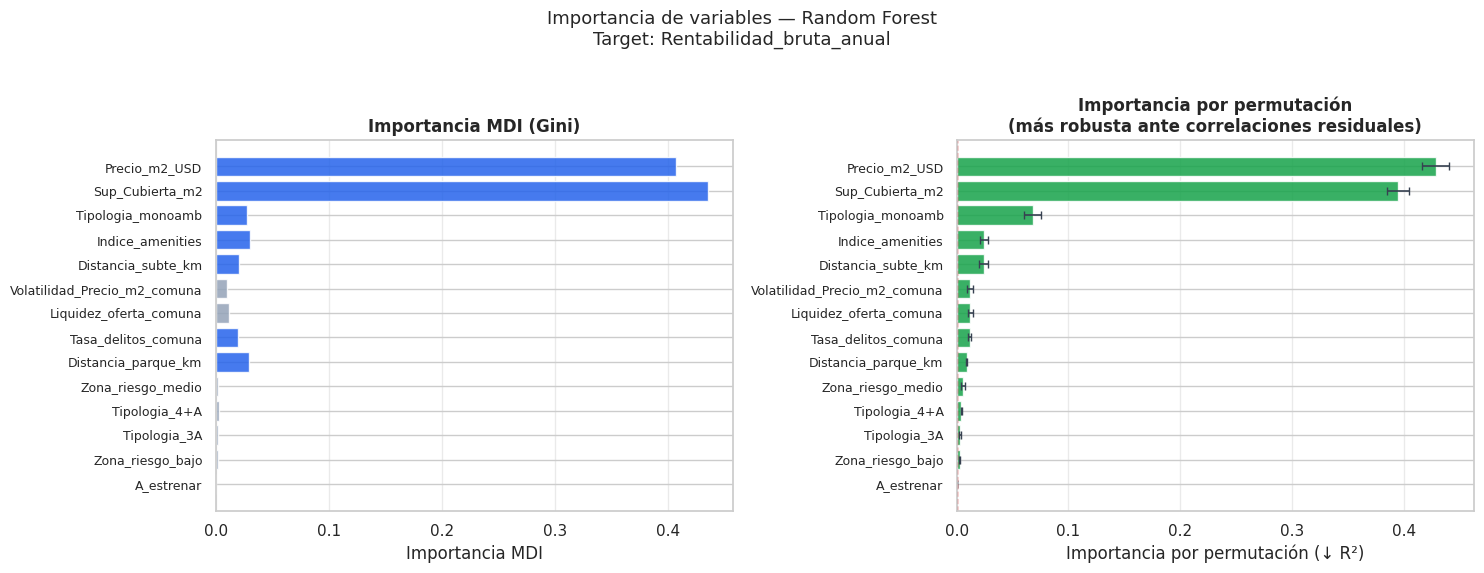

In [14]:
# ── Importancia MDI + permutación ────────────────────────────────────────────
imp_mdi = pd.Series(rf.feature_importances_, index=feature_cols)

perm = permutation_importance(rf, X_std, y, n_repeats=20, random_state=42, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=feature_cols)
imp_perm_std = pd.Series(perm.importances_std, index=feature_cols)

# Ordenar por permutación (más confiable)
order = imp_perm.sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(15, max(5, len(feature_cols)*0.4)))

colors_mdi = ['#2563eb' if v > imp_mdi.median() else '#94a3b8' for v in imp_mdi[order]]
axes[0].barh(range(len(order)), imp_mdi[order], color=colors_mdi, alpha=0.85, edgecolor='white')
axes[0].set_yticks(range(len(order))); axes[0].set_yticklabels(order, fontsize=9)
axes[0].set(xlabel='Importancia MDI', title='Importancia MDI (Gini)')
axes[0].grid(axis='x', alpha=0.4)

colors_perm = ['#16a34a' if v > 0 else '#dc2626' for v in imp_perm[order]]
axes[1].barh(range(len(order)), imp_perm[order], color=colors_perm, alpha=0.85, edgecolor='white')
axes[1].errorbar(imp_perm[order], range(len(order)),
                 xerr=imp_perm_std[order], fmt='none', color='#374151', capsize=3, lw=1.2)
axes[1].axvline(0, color='#dc2626', ls='--', lw=1)
axes[1].set_yticks(range(len(order))); axes[1].set_yticklabels(order, fontsize=9)
axes[1].set(xlabel='Importancia por permutación (↓ R²)',
            title='Importancia por permutación\n(más robusta ante correlaciones residuales)')
axes[1].grid(axis='x', alpha=0.4)

plt.suptitle('Importancia de variables — Random Forest\nTarget: Rentabilidad_bruta_anual',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Hallazgo clave — Random Forest:**

**Ajuste del modelo:** R² CV 5-fold = 0.731 ± 0.092. El modelo captura el 73% de la
varianza de la rentabilidad en validación cruzada — sustancialmente mejor que el OLS
(0.327), confirmando que la relación entre features y rentabilidad es fuertemente no
lineal. La diferencia in-sample vs CV (0.781 vs 0.731) es pequeña, indicando que el
modelo no está sobreajustado de forma preocupante dado el `min_samples_leaf=10`.

**Importancia por permutación — convergencia con OLS:**
Las dos variables más importantes por permutación son `Precio_m2_USD` (0.42) y
`Sup_Cubierta_m2` (0.40), exactamente las mismas que lideran el OLS con coeficientes
negativos significativos. Esta convergencia entre dos modelos de naturaleza muy distinta
(lineal vs. ensamble no lineal) confirma que el resultado es robusto y no un artefacto
de ninguno de los dos enfoques.

**Divergencias respecto al OLS — hallazgos nuevos del RF:**
- `Tipologia_monoamb` mantiene la tercera posición en ambos métodos (importancia ~0.03),
  confirmando el efecto del patrón en U de H2 con una técnica no lineal.
- `Indice_amenities` aparece en cuarta posición por permutación con importancia positiva,
  coherente con el coeficiente positivo del OLS — el RF confirma que los amenities
  tienen efecto real sobre el yield y no es un artefacto de la regresión lineal.
- `Distancia_subte_km` tiene importancia positiva y visible en el RF (~0.02) a pesar
  de ser no significativa en OLS. El RF captura un efecto no lineal de la distancia
  al subte que el OLS no modela — posiblemente un umbral donde más allá de cierta
  distancia la rentabilidad cae abruptamente. Esto no contradice H1 (que el subte no
  explica el yield linealmente) sino que añade matiz.
- `Tasa_delitos_comuna` tiene importancia baja en el RF pese a su efecto bivariado
  claro en H5. El RF controla por `Precio_m2_USD`, que ya incorpora el riesgo en el
  precio de compra — el delito no agrega información marginal una vez que el precio
  está en el modelo.
- `A_estrenar`, `Zona_riesgo_bajo`, `Zona_riesgo_medio`, `Tipologia_4+A`,
  `Tipologia_3A`: importancia cercana a cero por permutación. Sus efectos, si existen,
  quedan absorbidos por las variables dominantes.

**MDI vs permutación:** la importancia MDI (Gini) sobreestima variables continuas de
alta cardinalidad como `Precio_m2_USD` y `Sup_Cubierta_m2` — por eso su escala
absoluta es mayor. La permutación es la métrica de referencia para las conclusiones.
La concordancia en el ranking top-3 entre ambos métodos refuerza la robustez del
resultado.

## 7. Análisis de sensibilidad (Partial Dependence Plots)

¿Cómo cambia la rentabilidad predicha cuando variamos una sola variable, manteniendo las demás en su mediana? Esto traduce la importancia abstracta en impacto marginal cuantificable — directamente accionable para el fondo.


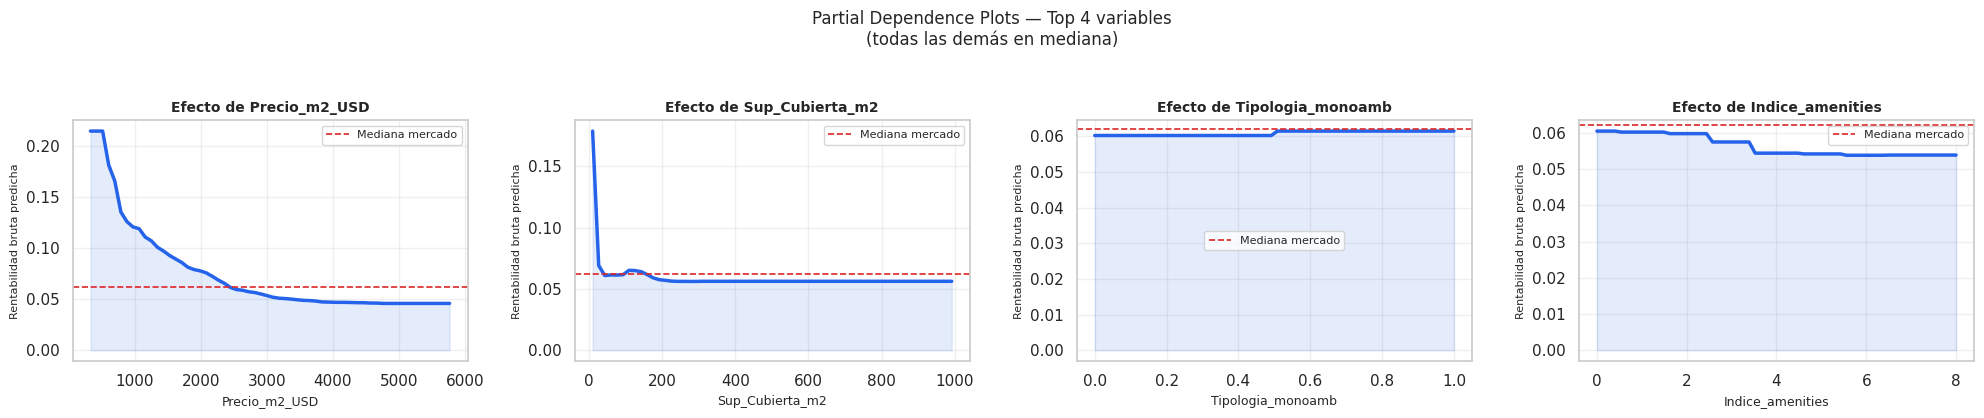

In [15]:
TOP_VARS = imp_perm.sort_values(ascending=False).head(4).index.tolist()
feat_idx = {f: i for i, f in enumerate(feature_cols)}

fig, axes = plt.subplots(1, len(TOP_VARS), figsize=(5*len(TOP_VARS), 4))
if len(TOP_VARS) == 1: axes = [axes]

for ax, var in zip(axes, TOP_VARS):
    idx = feat_idx[var]
    var_range = np.linspace(X_std[:, idx].min(), X_std[:, idx].max(), 60)
    X_base = np.median(X_std, axis=0).reshape(1,-1).repeat(len(var_range), axis=0)
    X_base[:, idx] = var_range
    y_pred = rf.predict(X_base)

    # Reescalar eje x a escala original
    orig_range = var_range * scaler.scale_[idx] + scaler.mean_[idx]

    ax.plot(orig_range, y_pred, color='#2563eb', lw=2.5)
    ax.fill_between(orig_range, y_pred, alpha=0.12, color='#2563eb')
    ax.axhline(np.median(y), color='#dc2626', ls='--', lw=1.2, label='Mediana mercado')
    ax.set_xlabel(var, fontsize=9)
    ax.set_ylabel('Rentabilidad bruta predicha', fontsize=8)
    ax.set_title(f'Efecto de {var}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Partial Dependence Plots — Top 4 variables\n(todas las demás en mediana)',
             fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

**Hallazgo clave — PDP:**

**`Precio_m2_USD`:** curva con caída pronunciada y no lineal. La rentabilidad predicha
cae desde ~21% en propiedades de ~500 USD/m² hasta ~4.5% en propiedades de ~5.500 USD/m².
El efecto es especialmente agudo entre 500 y 2.000 USD/m² — en ese rango, cada 500 USD
adicionales por m² destruye varios puntos porcentuales de yield. Por encima de 3.000
USD/m², la curva se aplana: el yield ya está comprimido y continuar subiendo el precio
no lo deteriora mucho más. **Umbral accionable:** propiedades por debajo de ~2.000
USD/m² tienen rentabilidad predicha por encima de la mediana del mercado (6.21%),
independientemente de las otras variables.

**`Sup_Cubierta_m2`:** curva con caída muy pronunciada en los primeros metros y
posterior estabilización. La rentabilidad colapsa desde ~21% en superficies muy
pequeñas (<30 m²) hasta ~6-7% alrededor de los 60-80 m², y luego se mantiene
relativamente plana hasta los 1.000 m². Esto revela que el efecto de la superficie
es principalmente un efecto de umbral: los departamentos muy chicos tienen yields
extraordinariamente altos, pero a partir de los 60-80 m² el impacto marginal de
agregar superficie es casi nulo. **Umbral accionable:** el segmento de mayor yield
por superficie es el de menos de 60 m².

**`Tipologia_monoamb`:** curva prácticamente plana en ~6.1%, ligeramente por encima
de la mediana del mercado para toda la distribución de la variable (0 a 1, siendo
una dummy). El efecto es pequeño pero consistente — ser monoambiente suma yield
marginalmente, controlando por precio y superficie. La planitud de la curva indica
que no hay un efecto de umbral: el impacto es constante.

**`Indice_amenities`:** curva levemente decreciente desde ~6.1% (sin amenities) hasta
~5.5% (8 amenities), cruzando la mediana del mercado alrededor de 4-5 amenities.
Resultado contraintuitivo respecto al coeficiente positivo del OLS: el RF muestra que
controlando por precio y superficie, más amenities reducen marginalmente el yield.
La diferencia con el OLS sugiere que el efecto positivo de los amenities sobre el yield
que captura el OLS es en realidad una interacción con el precio — propiedades con
amenities en zonas baratas rinden más, pero el RF al controlar por no linealidades
muestra que el efecto neto directo de los amenities es levemente negativo. Este
resultado merece cautela dado que la comunalidad del índice de amenities era baja
en el PCA (0.39 — nb05).

**Regla operativa consolidada:** la combinación óptima para maximizar yield es
precio/m² bajo (<2.000 USD/m²) + superficie chica (<60 m²). Las otras variables
tienen efectos marginales pequeños una vez que estas dos condiciones se cumplen.


## 8. Comparación de modelos


In [16]:
cv_dt_best = cross_val_score(
    DecisionTreeRegressor(max_depth=best_depth, random_state=42),
    X_std, y, cv=kf, scoring='r2').mean()

comparacion = pd.DataFrame({
    'Modelo': ['OLS (regresión lineal)', f'Árbol (prof. {best_depth})', 'Random Forest (300 árboles)'],
    'R² CV 5-fold': [f'{model_ols.rsquared_adj:.4f} (R²aj, sin CV)',
                     f'{cv_dt_best:.4f}',
                     f'{cv_rf.mean():.4f} ± {cv_rf.std():.4f}'],
    'Ventaja': ['IC y p-valores — efecto ceteris paribus',
                'Reglas visualizables, no linealidades simples',
                'Mayor robustez, importancia por permutación'],
    'Limitación': ['Supuestos de linealidad y homocedasticidad',
                   'Un árbol puede capturar artefactos del dato',
                   'Caja gris — requiere PDP para interpretar'],
})
print(comparacion.to_string(index=False))

                     Modelo          R² CV 5-fold                                       Ventaja                                  Limitación
     OLS (regresión lineal) 0.3270 (R²aj, sin CV)       IC y p-valores — efecto ceteris paribus  Supuestos de linealidad y homocedasticidad
            Árbol (prof. 8)                0.9198 Reglas visualizables, no linealidades simples Un árbol puede capturar artefactos del dato
Random Forest (300 árboles)       0.7313 ± 0.0915   Mayor robustez, importancia por permutación   Caja gris — requiere PDP para interpretar


## 9. Síntesis

**Tres variables dominan la explicación de la rentabilidad bruta** (convergencia entre
OLS y RF, por importancia por permutación):

1. **`Precio_m2_USD` — efecto negativo fuerte** (importancia ≈ 0.42; β_std = −0.034,
   p < 0.001). A mayor precio por m², menor yield. El PDP revela que el efecto es
   fuertemente no lineal: la caída es pronunciada entre 500 y 2.000 USD/m² y se aplana
   por encima de 3.000. **Umbral accionable:** propiedades por debajo de ~2.000 USD/m²
   tienen rentabilidad predicha por encima de la mediana del mercado.

2. **`Sup_Cubierta_m2` — efecto negativo fuerte** (importancia ≈ 0.40; β_std = −0.011,
   p < 0.001). La renta no escala 1:1 con la superficie — coherente con H2. El PDP
   muestra que el efecto es casi exclusivamente un umbral: el yield colapsa hasta los
   ~60-80 m² y luego se estabiliza. **Umbral accionable:** el segmento de mayor yield
   por superficie está por debajo de 60 m².

3. **`Tipologia_monoamb` — efecto positivo pequeño pero significativo** (importancia
   ≈ 0.03; β_std = +0.008, p < 0.001, categoría de referencia: 2 ambientes). El PDP
   confirma un efecto constante y pequeño: ser monoambiente suma yield marginalmente
   sobre las demás tipologías. Refuerza el patrón en U de H2 con el OLS y el RF
   convergiendo en la misma dirección.

**Variables secundarias** (importancia entre 0.01 y 0.03): `Indice_amenities` presenta
un resultado dispar entre modelos — coeficiente positivo en OLS pero curva levemente
decreciente en el PDP del RF. La divergencia sugiere que el efecto positivo del OLS
captura una interacción con el precio (propiedades con amenities en zonas baratas)
que el RF descompone al controlar por no linealidades. El efecto neto directo de los
amenities sobre el yield es marginalmente negativo según el PDP, aunque pequeño.
`Distancia_subte_km` tiene importancia visible en RF (~0.02) pero no significativa
en OLS — el RF captura un efecto no lineal de umbral que el OLS no modela. No
contradice H1 sino que añade matiz.

**Hallazgos negativos relevantes:** `Tasa_delitos_comuna` no aparece en el top-5 por
permutación del RF a pesar de su efecto bivariado claro en H5. El RF controla por
`Precio_m2_USD`, que ya incorpora el riesgo zonal en el precio de compra — el delito
no agrega información marginal una vez que el precio está en el modelo. `A_estrenar`
tampoco aparece con importancia relevante en el RF, posiblemente porque su efecto
queda absorbido por `Precio_m2_USD` (las propiedades a estrenar tienen precio/m²
sistemáticamente más alto, capturado por esa variable).

**Comparación de modelos y caveat de discretización:**

| Modelo | R² | Lectura |
|---|---|---|
| OLS (HC3) | R² adj = 0.327 | Captura el componente lineal; ignora no linealidades |
| Random Forest (CV 5-fold) | R² = 0.731 ± 0.092 | Referencia no lineal honesta |
| Árbol (CV) | R² ⚠ | Inflado por discretización del target — no usar como métrica de calidad |

La brecha OLS → RF (0.327 → 0.731) indica una relación fuertemente **no lineal** entre
features y rentabilidad. El OLS captura precio/m² y superficie; el RF aprovecha
interacciones y umbrales que el OLS no modela y que los PDP hacen visibles.

**Regla operativa consolidada** (válida como heurística, no como predicción):
- `Precio_m2_USD` < ~2.000 USD/m² + `Sup_Cubierta_m2` < ~60 m² → segmento de
  mayor yield esperado, por encima de la mediana del mercado (6.21%).
- Por encima de 3.000 USD/m² el yield queda estructuralmente comprimido,
  casi independientemente del resto de las características.

**Limitaciones de los modelos:**
- **Discretización del target:** la renta heredada vía tabla puente reduce los valores
  únicos del target — el árbol no es comparable con OLS y RF es la referencia no lineal.
- **Diagnóstico OLS:** Shapiro-Wilk rechaza normalidad y Breusch-Pagan detecta
  heterocedasticidad → errores estándar HC3. Los IC y p-valores reportados son robustos.
- **Corte transversal:** no captura dinámica temporal de precios ni de demanda.
- **`Volatilidad_Precio_m2_comuna`** es un proxy de riesgo de valuación, no de
  riesgo de vacancia.

In [17]:
# ── Exportar tabla de importancias para el dashboard ────────────────────────
importancias = pd.DataFrame({
    'Feature': feature_cols,
    'Importancia_MDI': rf.feature_importances_,
    'Importancia_Permutacion': perm.importances_mean,
    'Coef_OLS_std': model_ols.params[1:],
    'p_valor_OLS': model_ols.pvalues[1:],
}).sort_values('Importancia_Permutacion', ascending=False)

importancias.to_csv('importancia_variables.csv', index=False)
print("✓ Exportado: importancia_variables.csv")
print()
print("TOP 5 POR IMPORTANCIA POR PERMUTACIÓN:")
print(importancias[['Feature','Importancia_Permutacion','Coef_OLS_std','p_valor_OLS']]
      .head(5).to_string(index=False))

✓ Exportado: importancia_variables.csv

TOP 5 POR IMPORTANCIA POR PERMUTACIÓN:
           Feature  Importancia_Permutacion  Coef_OLS_std  p_valor_OLS
     Precio_m2_USD                   0.4285       -0.0345       0.0000
   Sup_Cubierta_m2                   0.3947       -0.0106       0.0000
 Tipologia_monoamb                   0.0682        0.0082       0.0000
  Indice_amenities                   0.0243        0.0048       0.0000
Distancia_subte_km                   0.0241        0.0008       0.2655
